In [1]:
# Importing necessary library
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import pywt
import pandas as pd
import os
import time
from scipy import signal
from stingray import lightcurve
import sys
from stingray import Bispectrum
import warnings
import csv
warnings.filterwarnings('ignore')
%matplotlib inline

c:\Users\farra\anaconda3\envs\eeg_env\lib\site-packages\stingray\utils.py:54: UserWarning: Numba not installed. Faking it
  warnings.warn("Numba not installed. Faking it")


In [2]:
# file that will be skipped because of information loss
# zeros_test = ['co2a0000368_91.csv', 'co2c0000341_26.csv']
# zeros_train = ['co2a0000368_0.csv', 'co2a0000368_1.csv', 'co2a0000368_2.csv', 'co2a0000368_3.csv', 'co2a0000368_4.csv', 'co2a0000368_5.csv', 'co2c0000341_27.csv']

### Menghitung Matriks Cumulant orde ke-3

In [3]:
def calcCumulantOrde3(df_data, t, lag):
    # Compute the bispectrum of the signal
    lc = lightcurve.Lightcurve(t,df_data.T)
    bs = Bispectrum(lc, maxlag=lag)

    # Plot the bispectrum using contour plots
    # plt.contour(bs.freq, bs.freq, bs.bispec_mag)
    # plt.xlabel('f1')
    # plt.ylabel('f2')
    # plt.show()

    # Plot the bispectrum using mesh plots
    # fig = plt.figure()
    # ax = fig.add_subplot(111, projection='3d')
    # X, Y = np.meshgrid(bs.freq, bs.freq)
    # ax.plot_surface(X, Y, bs.bispec_mag)
    # ax.set_xlabel('f1')
    # ax.set_ylabel('f2')
    # ax.set_zlabel('Bispectrum')
    # plt.show()

    return bs.bispec_mag

### Creating Filter Matrix

In [4]:
def gkernel(k=2, l=1, sig=20):
    """
    Gaussian Kernel Creator via given length and sigma
    """

    ax = np.linspace(-(l - 1) / 2., (l - 1) / 2., l)
    bx = np.linspace(-(k - 1) / 2., (k - 1) / 2., k)

    xx, yy = np.meshgrid(ax, bx)

    kernel = np.exp(-0.5 * (np.square(xx) + np.square(yy)) / np.square(sig))

    return kernel / np.max(kernel)

### Creating feature matrix

In [13]:
def create_feature(bispectrum, pyramid, fil_size):
    fsize = len(fil_size)
    feature_matrix = np.zeros([fsize,fsize])
    xtrack = 0
    ytrack = 0
    for xdim in range(fsize):
        for ydim in range(fsize):
            x,y = fil_size[xdim], fil_size[ydim]
            print(xtrack, ytrack)
            
            feature_matrix[xdim][ydim] = np.mean(bispectrum[xtrack:xtrack+x, ytrack:ytrack+y] * pyramid[xtrack:xtrack+x, ytrack:ytrack+y])
            ytrack = ytrack+y
        ytrack = 0
        xtrack = xtrack+x
    final_feature = feature_matrix[np.triu(np.ones_like(feature_matrix, dtype=bool))]
    final_feature = final_feature[~np.isnan(final_feature)]

    return final_feature

    # x, y = np.meshgrid(np.arange(256), np.arange(256))
    # z = overall
    # z = z[:-1, :-1]
    # z_min, z_max = -np.abs(z).max(), np.abs(z).max()

    # plt.subplot()

    # plt.pcolormesh(x, y, z, 
    #             cmap =cm.coolwarm, 
    #             vmin = z_min, 
    #             vmax = z_max,
    #             edgecolors = 'face',
    #             shading ='flat')

    # plt.title('Filter')

    # # set the limits of the plot
    # # to the limits of the data
    # plt.axis([x.min(), x.max(), y.min(), y.max()])

    # plt.colorbar()
    # plt.show()

    # fig, ax = plt.subplots(subplot_kw={"projection": "3d"}, figsize=(10, 5))
    # ax = plt.axes(projection="3d")
    # x2d, y2d = np.meshgrid(np.arange(256), np.arange(256))
    # ax.plot_surface(x2d, y2d, overall, cmap=cm.coolwarm,
    #                         linewidth=0, antialiased=False)
    # ax.set_xlabel('x')
    # ax.set_ylabel('y')
    # ax.set_zlabel('height')
    # plt.show()

### Persiapan data

In [6]:
# Define sampling frequency
fs = 256
t = np.arange(0, 1, 1/(fs*1))
t.shape

(256,)

In [7]:
def get_csv_EEG(filename):
    # Load data from CSV
    df_data = pd.read_csv(filename)
    return df_data, df_data.columns


### Perhitungan Feature Bispectrum

In [8]:
def create_pyramid(x, y):
    pyramid = np.zeros([x,y])
    x = pyramid.shape[0]
    y = pyramid.shape[1]

    for i in range(x // 2):
        for j in range(i, x - i):
            for h in range(i, y - i):
                pyramid[j, h] = i
    pyramid = pyramid/np.max(pyramid)
    return pyramid

In [9]:
def extract_feature(directory, lag, destination, filter_dim = 5, segment_time=1):
    fs = 256
    t = np.arange(0, 1, 1/(fs * segment_time))

    bis_dim = lag
    big_fil_size = bis_dim //2
    sigma = bis_dim//8
    if sigma == 0:
        sigma = 1
    fil_size = [big_fil_size // (2 ** i) for i in range(filter_dim)]
    
    if sum(fil_size) != bis_dim:
            fil_size = [value for value in fil_size if value != 0]
            if len(fil_size) == 1:
                fil_size.append(fil_size[0])
    
    fil_size[-1] = fil_size[-2] 
    pyramid = np.zeros([bis_dim,bis_dim])
    xtrack, ytrack = 0,0
    # print(fil_size)
    for xdim in range(len(fil_size)):
        for ydim in range(len(fil_size)):
            x,y = fil_size[xdim], fil_size[ydim]
            pyramid[xtrack:xtrack+x, ytrack:ytrack+y] = create_pyramid(x, y)
            ytrack = ytrack+y
        ytrack = 0
        xtrack = xtrack+x
    recap = pd.DataFrame(columns=['Wall Time', 'CPU Time'])
    for foldername in os.listdir(directory):
        folder = os.path.join(directory, foldername)
        if os.path.isdir(folder):
            des_dir = os.path.join(destination +"_" + str(lag), foldername).lower()
            files = os.listdir(folder)
            for filename in files:
                cpu_start = time.process_time()
                wt_start = time.time()
                # if filename in zeros_train or filename in zeros_test:
                #     continue
                rel_path = os.path.join(directory, foldername, filename)
                # if 'metadata' in filename.lower():
                #     continue
                # trial_number = filename.split('.')[0].split('_')[1]
                des_file = foldername+'_'+ filename + '_bispectrum' +'.npy'
                if not os.path.exists(des_dir):
                    os.makedirs(des_dir)
                des_path = os.path.join(des_dir, des_file)
                if os.path.exists(des_path):
                    continue
                df_data, channel_name = get_csv_EEG(rel_path)
                bispectrum = []
                for channel in channel_name:
                    magnitude = calcCumulantOrde3(df_data[channel], t, lag)
                    magnitude = magnitude[:256, :256] # take 4th quadrant
                    feature = create_feature(magnitude,pyramid,fil_size)
                    bispectrum.append(feature)
                bispectrum = np.array(bispectrum)
                bispectrum = bispectrum.flatten()
                np.save(des_path, bispectrum)
                wt_end = time.time()
                cpu_end = time.process_time()
                wall_time = wt_end - wt_start
                cpu_time = cpu_end - cpu_start
                recap_temp = pd.DataFrame([[wall_time, cpu_time]],columns=recap.columns)
                recap = pd.concat([recap, recap_temp], ignore_index=True)
                # pd.DataFrame(RWB.T).to_csv(des_path, index=False)
    recap_dir = os.path.join('./logs/Execution',directory.split('/')[1])
    if not os.path.exists(recap_dir):
        os.makedirs(recap_dir)
    recap_path = os.path.join(recap_dir,'recap_bispectrum_pyramid'+str(lag)+'.csv')
    recap.to_csv(recap_path)    


### Test

In [20]:
def extract_test(filename, lag, pyramid, fil_size):
    
    # if filename in zeros_train or filename in zeros_test:
    #     pass
    # if 'metadata' in filename.lower():
    #     pass
    
    df_data, channel_name = get_csv_EEG(filename)
    bispectrum = []
    # for channel in channel_name:
    magnitude = calcCumulantOrde3(df_data[channel_name[1]], t, lag)
    feature = create_feature(magnitude,pyramid,fil_size)
    bispectrum.append(feature)
    bispectrum = np.array(bispectrum)
    bispectrum = bispectrum.flatten()
    return bispectrum
                


0 0
0 128
0 192
0 224
0 240
128 0
128 128
128 192
128 224
128 240
192 0
192 128
192 192
192 224
192 240
224 0
224 128
224 192
224 224
224 240
240 0
240 128
240 192
240 224
240 240
(15,)
[5.82594931e+00 1.16705341e+01 3.68946244e+01 7.61590163e+01
 4.01739511e+02 5.03571525e+01 3.92001272e+02 1.21286866e+03
 6.64710857e+03 1.91802405e+03 7.37334185e+03 5.12583262e+04
 1.44916476e+04 1.09910723e+05 1.20350129e+06]


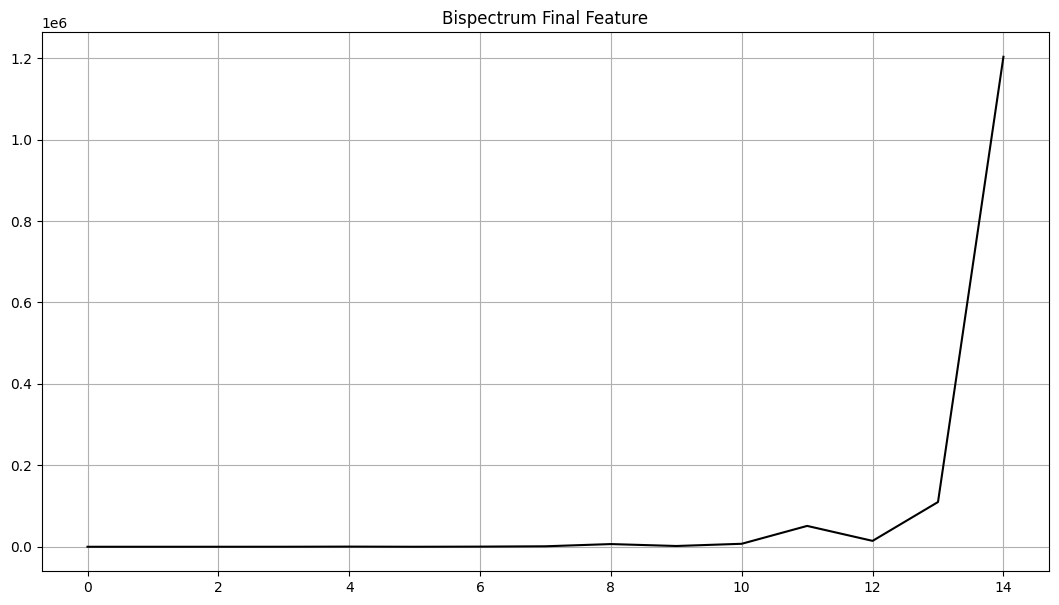

In [28]:
bis_dim = 256
filter_dim = 5
big_fil_size = bis_dim //2
fil_size = [big_fil_size // (2 ** i) for i in range(filter_dim)]
fil_size[-1] = fil_size[-2] 
pyramid = np.zeros([bis_dim,bis_dim])
xtrack, ytrack = 0,0
for xdim in range(filter_dim):
    for ydim in range(filter_dim):
        x,y = fil_size[xdim], fil_size[ydim]
        pyramid[xtrack:xtrack+x, ytrack:ytrack+y] = create_pyramid(x,y)
        ytrack = ytrack+y
    ytrack = 0
    xtrack = xtrack+x
bs = extract_test('datasets/segmented_1 seconds/autism/Bader/segment_189.csv', 256, pyramid, fil_size)
print(bs.shape)
print(bs)

plt.figure(figsize=(13,7))
plt.plot(bs, color='black')
plt.title("Bispectrum Final Feature")
plt.grid()
plt.show()

In [12]:
bis_dim = 128 #lag
filter_dim = 5

big_fil_size = bis_dim //2
sigma = bis_dim//8
if sigma == 0:
    sigma = 1
fil_size = [big_fil_size // (2 ** i) for i in range(filter_dim)]

if sum(fil_size) != bis_dim:
        fil_size = [value for value in fil_size if value != 0]
        if len(fil_size) == 1:
            fil_size.append(fil_size[0])

fil_size[-1] = fil_size[-2] 
pyramid = np.zeros([bis_dim,bis_dim])
xtrack, ytrack = 0,0
# print(fil_size)
for xdim in range(len(fil_size)):
    for ydim in range(len(fil_size)):
        x,y = fil_size[xdim], fil_size[ydim]
        pyramid[xtrack:xtrack+x, ytrack:ytrack+y] = gkernel(x, y, sigma)
        ytrack = ytrack+y
    ytrack = 0
    xtrack = xtrack+x

bs = extract_test('datasets/segmented_1 seconds/autism/Bader/segment_1001.csv', 256, pyramid, fil_size)
print(bs.shape)
print(bs)

(240,)
[117.7364942   90.53831327  90.31731242  96.03612476  96.69452439
  96.36962157 116.71006286 134.56415107 141.67390955 144.09816854
 168.67027537 177.24002266 199.72501998 209.4022029  219.74216108
 437.80874664 259.94121223 223.43470247 213.68687413 207.12383155
 243.99729285 276.01585564 277.94708177 275.27746325 326.56988048
 333.21376584 331.70669393 343.81480047 342.50350064 341.92457124
 607.47628402 403.50392158 358.25835925 283.79521896 385.44015944
 351.01498393 361.74996421 314.82995535 458.29674413 407.78034468
 360.12478447 526.35909028 318.70344308 467.29804632 688.2427307
 110.42557939 111.32730398  92.03145398  98.58767016 134.24878476
  52.41353534  61.5301776   85.55590904 138.6170357   86.47697701
 121.85217192 198.07615731 172.19027454 282.82377119 462.35062359
   9.00795341   9.51118012  10.99429214  24.52163447  18.21605286
   7.38168484  10.86063563  30.41414975  26.63146897  19.4261429
  54.73118773  48.13592297 154.87852331 136.17675445 120.4820478
 167.2

### Main Program

In [13]:
SEGMENT_TIME = 1

directory_segmented = f"datasets/segmented_{SEGMENT_TIME} seconds"
directory_feature = f"datasets/features/bispectrum_pyramid/segment_{SEGMENT_TIME} seconds"
directory_logs = f"logs/Execution/bispectrum_pyramid/segmented_{SEGMENT_TIME} seconds"

In [14]:
lags = [128]
for lag in lags:
    extract_feature(os.path.join(directory_segmented, "autism"), lag, os.path.join(directory_feature, "autism"), segment_time=SEGMENT_TIME)
    extract_feature(os.path.join(directory_segmented, "normal"), lag, os.path.join(directory_feature, "normal"), segment_time=SEGMENT_TIME)

In [15]:
lags = [64]
for lag in lags:
    extract_feature(os.path.join(directory_segmented, "autism"), lag, os.path.join(directory_feature, "autism"), segment_time=SEGMENT_TIME)
    extract_feature(os.path.join(directory_segmented, "normal"), lag, os.path.join(directory_feature, "normal"), segment_time=SEGMENT_TIME)

In [ ]:
# data = np.loadtxt('../out.csv', delimiter=",", skiprows=1, usecols=range(3,259))
# channel_name = np.loadtxt('../out.csv', delimiter=",", skiprows=1, usecols=1, dtype='str', encoding='utf-8')

# df_data = pd.DataFrame(data.T, columns=channel_name)
# df_data = df_data.drop(columns=['X', 'Y', 'nd'])
# bispectrum = []
# for channel in df_data.columns:
#     magnitude = calcCumulantOrde3(df_data[channel], t, 256)
#     bispectrum.append(magnitude)
# bispectrum = np.array(bispectrum)
# np.save('../bispectrum.npy', bispectrum)
# x = np.load('../bispectrum.npy')

# (bispectrum == x).all()